# Phase-Space Reconstruction from Delayed Coordinates
----------------------------------------------------------------------------

## Objective
Use delayed coordinates to reconstruct the geometric structure of a dynamical system from a single observed signal.

This notebook extends the phase-space representation from Day 3 by varying the delay parameter and examining how delayed embedding reveal the underlying system geometry. The goal is to show how a one-dimensional time series can provide a higher dimensional view of system dynamics. 

----------------------------------------------------------------------------

## Method Overview
This notebook proceeds in three stages:
1. Recreate the synthetic oscillatory system.
2. construct delayed-coordinate embeddings.
3. Compare reconstructed phase-space plots for different delay values.

Thie provides a geometric interpretation of the same oscilatory system previously examined through state estimation, residual analysis, spectral analysis, and phase-space visualization.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(72)

### Finding Our Old Friend, Mr. Synthetic Signal
In the interest of cohesion, signal construction should remain comparable to all week 2 notebook

In [3]:
t = np.arange(0,200)

true_signal = np.sin(2*np.pi*t/30)

noise = np.random.normal(0, 0.4, len(t))

observations = true_signal + noise

### Signal Choice for Reconstruction
We are selecting the **Kalman Estimate** instead of the raw observations so the geometric structure is easier to interpret.

In [6]:
x = np.zeros(len(t))
P = np.zeros(len(t))

Q = 0.01
R = 0.2

for i in range(1, len(t)):
    x_pred = x[i - 1]
    P_pred = P[i - 1] + Q

    K = P_pred / (P_pred + R)

    x[i] = x_pred + K * (observations[i] - x_pred)
    P[i] = (1 - K) * P_pred

### Delayed Embedding
We now construct a 2D phase space using a delay coordinate:
$$
\text{(}\mathit{x}\:(\mathit{t})\:,\:\mathit{x}\:(\mathit{t+r}\:))
$$
Starting with **5 time steps**

In [7]:
tau = 5

x1 = x[:-tau]
x2 = x[tau:]

#### Reconstructed Phase Space

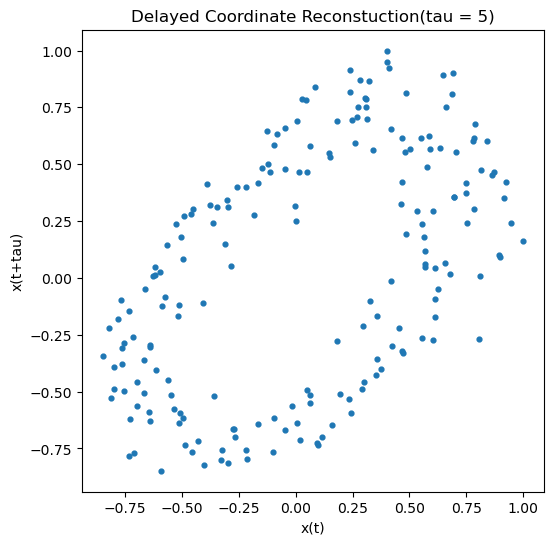

In [8]:
plt.figure(figsize=(6,6))
plt.scatter(x1, x2, s=12)

plt.title(f"Delayed Coordinate Reconstuction(tau = {tau})")
plt.xlabel("x(t)")
plt.ylabel("x(t+tau)")
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

#### Comparing Multiple Delay Values

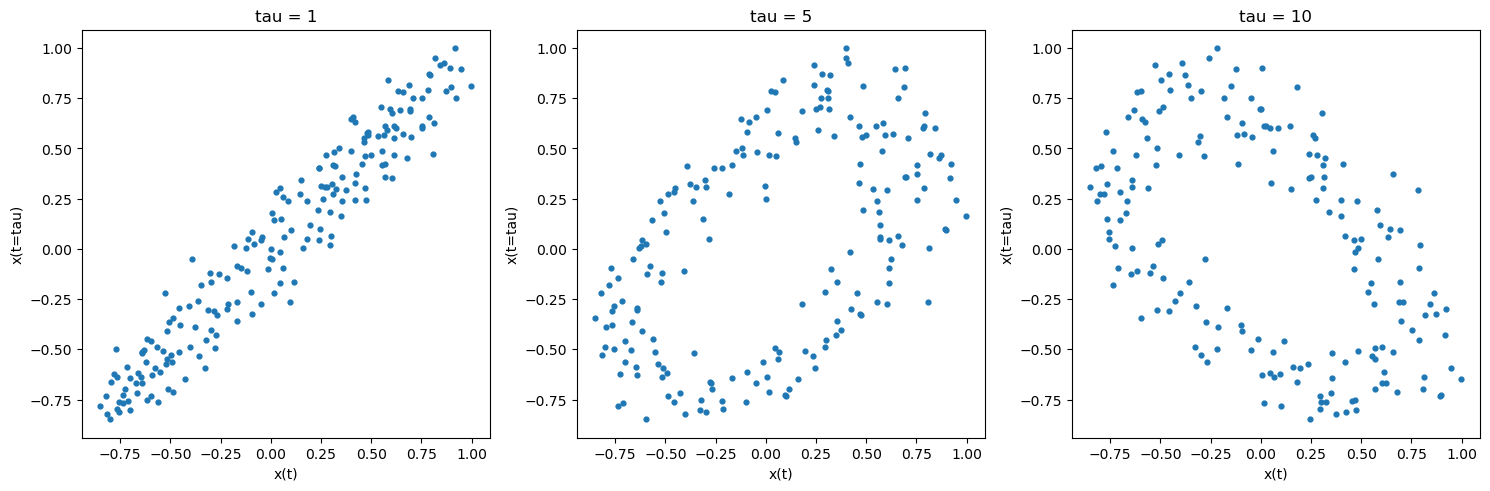

In [9]:
taus = [1, 5, 10]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, tau in zip(axes, taus):
    x1 = x[:-tau]
    x2 = x[tau:]

    ax.scatter(x1, x2, s=12)
    ax.set_title(f"tau = {tau}")
    ax.set_xlabel("x(t)")
    ax.set_ylabel("x(t=tau)")
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

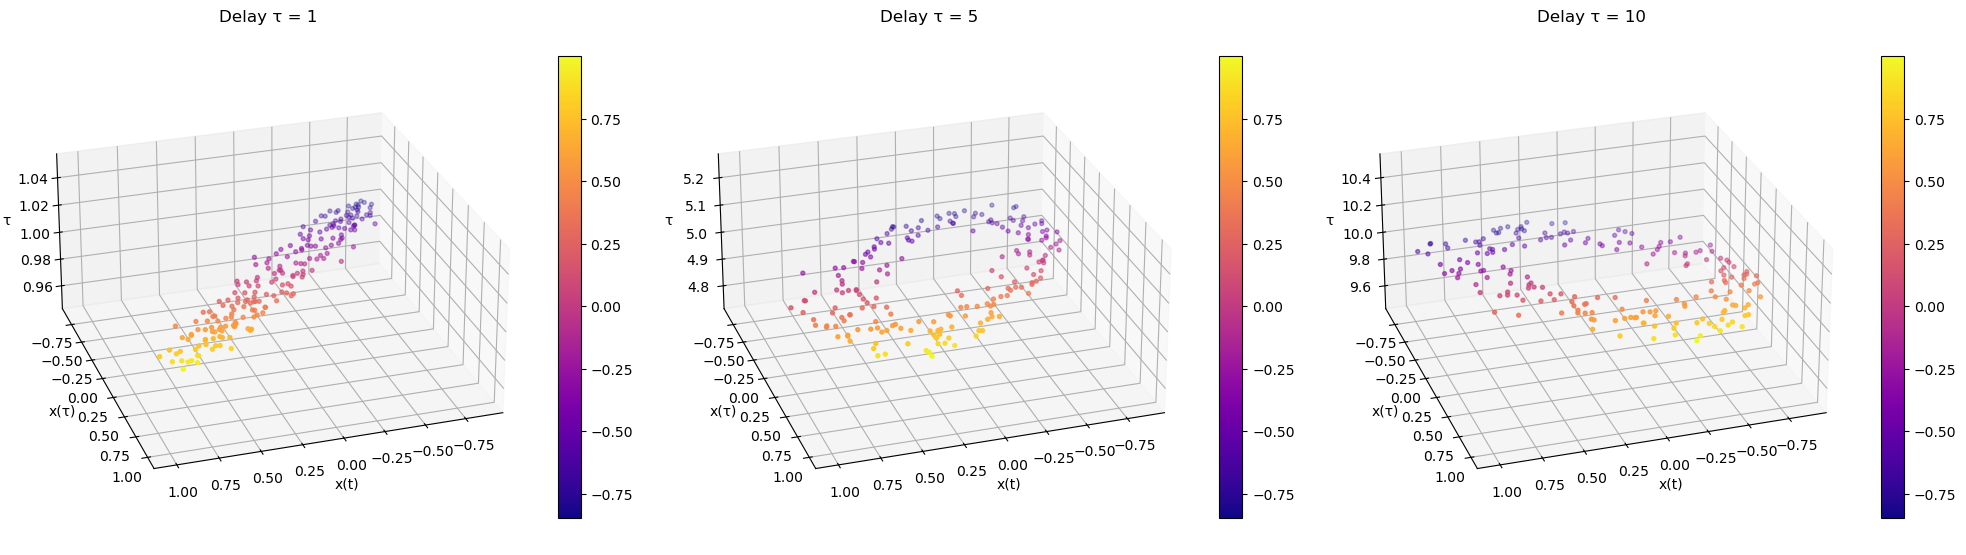

In [50]:
from mpl_toolkits.mplot3d import Axes3D
taus = [1, 5, 10]

x_vals = []
y_vals = []
z_vals = []

fig = plt.figure(figsize=(20,8))
for i, tau in enumerate(taus):

    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    
    x1 = x[:-tau]
    x2 = x[tau:]
    z = np.full_like(x1, tau)

    sc = ax.scatter(x1, x2, z, 
                    c=x2,
                   cmap='plasma',
                   s=8)

    ax.set_title(f"Delay τ = {tau}")
    ax.set_xlabel("x(t)")
    ax.set_ylabel("x(τ)")
    ax.set_zlabel("τ")
    ax.set_box_aspect((1,1,0.5))
    ax.view_init(elev=26, azim=72)
    ax.grid(alpha=0.4)

    fig.colorbar(sc, ax=ax, shrink=0.6)

plt.tight_layout()
plt.show()

#### Interpretation
As the delay increases, the reconstructed orbit rotates and spreads out. With smal delay values ,the coordinates remian highly correated, producing a narrow tilted ellipse. As the delay becomes larger, that correlation weakens, the orbit opens up, and the geometry rotates toward a different orientation. 

In this example, increasing the delay from $\mathbb{tau}=1$ to $\mathbb{tau}=10$ produces something close to a quarter turn in the reconstructed shape, along with greater in the point cloud. This reflects the changing phase relationship between the delayed coordinates.

*This is a small step inside of **phase-space reconstruction** as a method, not just a plot.*

----------------------------------------------------------------------------

### Summary
This notebook used delayed coordinates to reconstuct the phase-space geometry of an oscillatory system from a single signal. By plotting the signal against delayed versions of itself, the analysus showed how the apparent geometry depends on the delay parameter.

Small delay values produced tightly orrelated elliptical structures, while larger delats rotated and spread the orbit. this demonstrates that delayed-coordinae embedding can recover meaningful geometric structure from a one-dimensional time series, but the quality and interpretability if the reconstruction depend on the delay choice.

The reconstruction extends the earlier phase-space work by treating delayed coordinates as a general method for exploring system dynamics from limited observations. 